# Dataset Description

The Titanic dataset contains passenger information from the RMS Titanic, including demographic details, ticket class, fare, and survival status. It is used to build a classification model that predicts whether a passenger survived the disaster based on the available features.


##Importing the Libraries and Loading the Dataset


In [1]:
import pandas as pd  #pandas for handling datasets
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

# Load the CSV file into a DataFrame
df = pd.read_csv("Titanic-Dataset.csv")

# Displaying a success message
print("Dataset loaded successfully!")

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv
Dataset loaded successfully!


In [2]:
df.head()  #This is to display the first 5 rows of the uploaded file

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploring the Dataset Information and Data Types


In [5]:
print("Dataset Shape:", df.shape) # Display dataset dimensions (rows and columns)

# Display column names, data types, and non-null counts
df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Display statistical summaries of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Checking for Missing Values


In [7]:
# Count missing values in each column
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


##Data Preprocessing - Handling Missing Values


In [16]:
# Check missing values in each column
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Missing values before handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
# Verify missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


##Analyzing the target class distribution

Survived
0    549
1    342
Name: count, dtype: int64


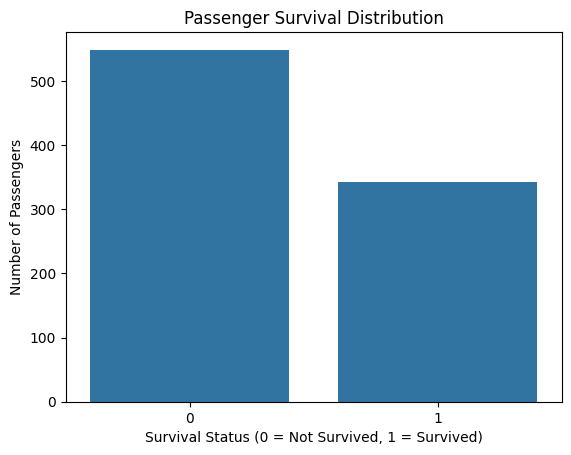

In [18]:
# Counting for each passengers in each survival category
print(df["Survived"].value_counts())

# Visualizing the distribution of the target variable
sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival Status (0 = Not Survived, 1 = Survived)")
plt.ylabel("Number of Passengers")
plt.show()

##Correlation Heatmap

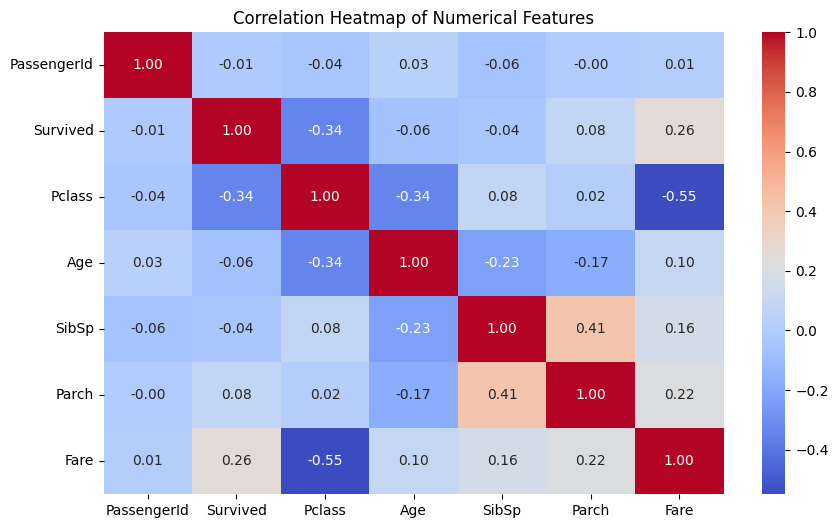

In [19]:
# Selecting the numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=["number"])

# Calculating the correlation between numerical variables
correlation = numeric_df.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Analyzing Survival Distribution by Gender


Survived    0    1
Sex               
female     81  233
male      468  109


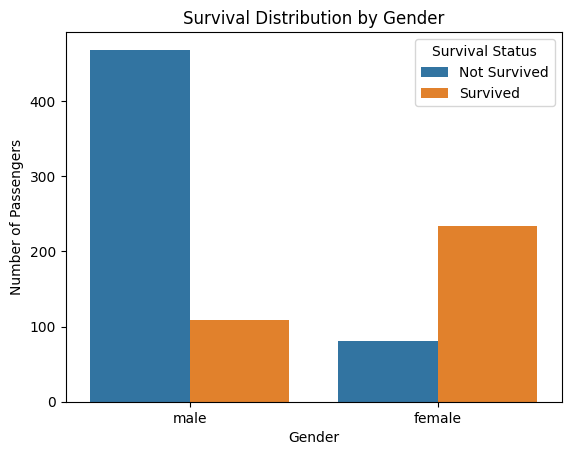

In [20]:
# Displaying survival counts based on gender
print(pd.crosstab(df["Sex"], df["Survived"]))

# Visualizing survival distribution by gender
sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survival Status", labels=["Not Survived", "Survived"])
plt.show()

##Analyzing Survival Distribution by Passenger Class


Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


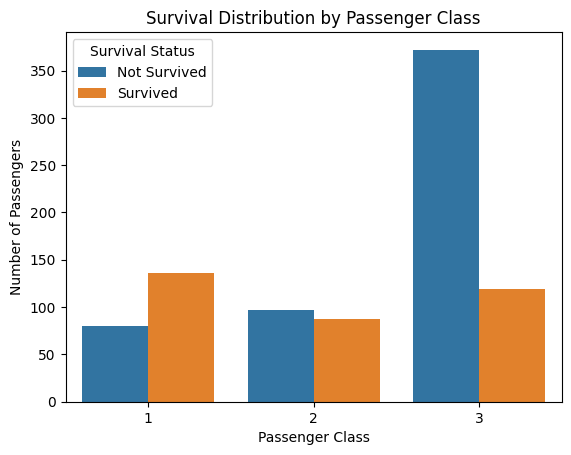

In [21]:
# Displaying survival counts across passenger classes
print(pd.crosstab(df["Pclass"], df["Survived"]))

# Visualizing survival distribution across passenger classes
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survival Status", labels=["Not Survived", "Survived"])
plt.show()

##Now Analyzing the Age Distribution of Passengers

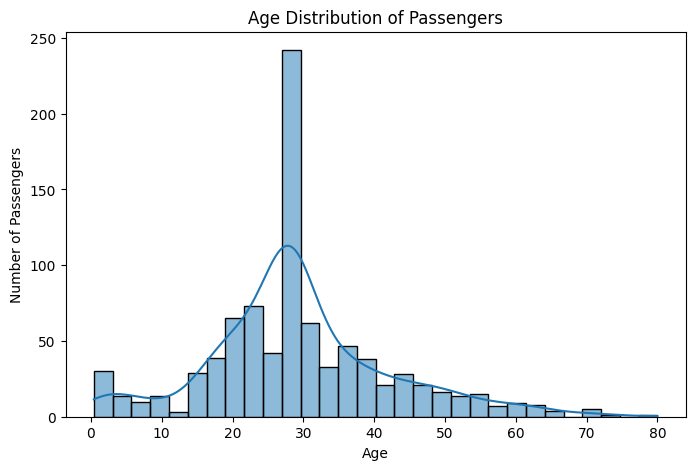

In [22]:
# Visualizing the age distribution of passengers
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

##Preparing the Dataset for Model Traini

In [24]:
print("Available Columns:", df.columns.tolist())

# Separating the target variable from the input features
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Displaying the shapes of the input features and target variable
print("Input Features Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Available Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']
Input Features Shape: (891, 10)
Target Variable Shape: (891,)


##Encoding Categorical Features

In [25]:
categorical_columns = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True, dtype=int)

# Displaying the encoded dataset
print("Encoded Features:")
display(X.head())

# Displaying the updated dataset dimensions
print("Updated Feature Shape:", X.shape)

Encoded Features:


,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,3,35.0,0,0,8.0500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Updated Feature Shape: (891, 1579)


##Splitting the Dataset into Training and Testing Sets

In [26]:
# Importing the function for splitting the dataset
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (712, 1579)
Testing Features Shape: (179, 1579)
Training Target Shape: (712,)
Testing Target Shape: (179,)


##Building and Training the Random Forest Classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initializing the Random Forest model with selected hyperparameters
rf_model = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42) #Using 100 decision trees to build the ensemble.

# Training the model using the training dataset
rf_model.fit(X_train, y_train)

# Displaying the model training confirmation
print("Random Forest model training completed successfully!")

Random Forest model training completed successfully!


##Confusion Matrix

In [29]:
# Generating predictions using the trained Random Forest model
y_pred = rf_model.predict(X_test)


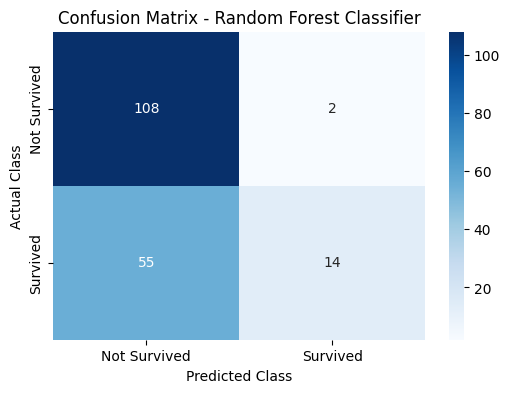

In [30]:
# Importing the confusion matrix and its visualization tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Visualizing the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"])

plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

##Evaluating Model Performance Using Precision, Recall, and F1-Score

In [31]:
# Importing classification evaluation metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

Precision: 0.875
Recall: 0.2029
F1-Score: 0.3294

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.66      0.98      0.79       110
    Survived       0.88      0.20      0.33        69

    accuracy                           0.68       179
   macro avg       0.77      0.59      0.56       179
weighted avg       0.74      0.68      0.61       179



##Evaluating Model Performance Using the ROC-AUC Curve

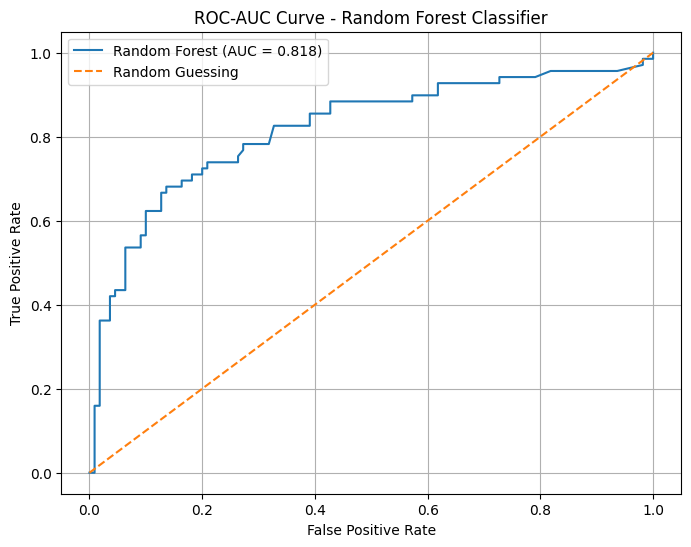

ROC-AUC Score: 0.8183


In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculating the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Visualizing the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")

plt.title("ROC-AUC Curve - Random Forest Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Displaying the final ROC-AUC score
print("ROC-AUC Score:", round(roc_auc, 4))

##Now looking at the feature importance

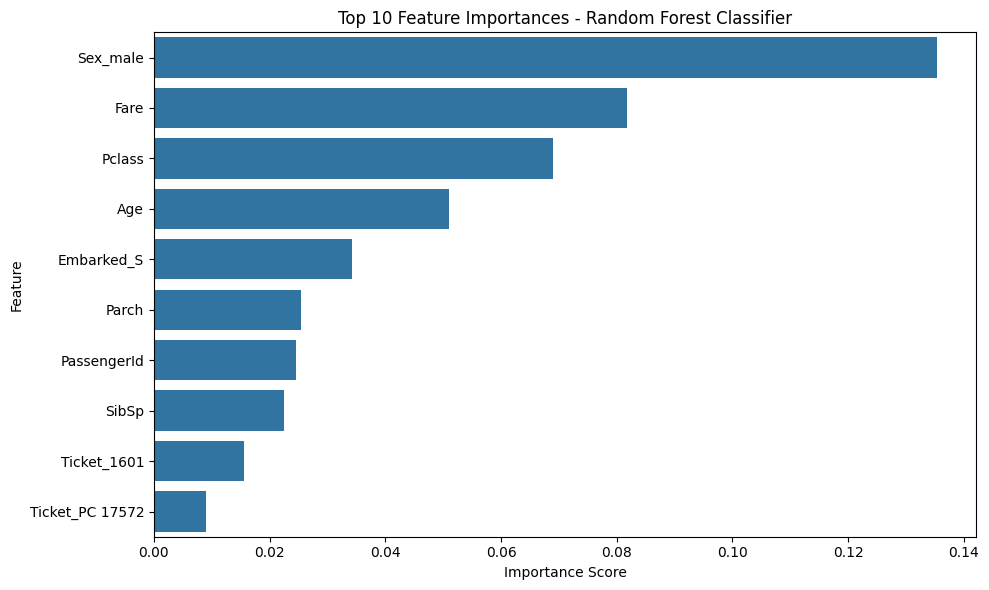

,Feature,Importance
896,Sex_male,0.135381
5,Fare,0.081741
1,Pclass,0.068971
2,Age,0.050958
1578,Embarked_S,0.034317
4,Parch,0.025456
0,PassengerId,0.024637
3,SibSp,0.022553
976,Ticket_1601,0.015599
1483,Ticket_PC 17572,0.008970


In [35]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

# Selecting the 10 most important features
top_features = feature_importance.head(10)

# Visualizing the 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 10 Feature Importances - Random Forest Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Displaying the feature importance rankings
display(top_features)

#CONCLUSION

###Evaluating passenger survival using ensemble learning.Analyzing classification performance through multiple metrics & Identifying influential features using feature importance.
